In [50]:
!pip install datasets transformers torch torchvision pyyaml -q

In [51]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import yaml
from datasets import load_dataset
from PIL import Image
import matplotlib.pyplot as plt
from collections import Counter
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
# Checking GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found.")

# Setting random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Seed set: {SEED}")

# Loading config
config = {
    "seed": 42,
    "image_size": 224,
    "max_text_len": 128,
    "batch_size": 8,
    "num_epochs": 20,
    "learning_rate": 1e-3,
    "hidden_dim": 256,
    "embed_dim": 128,
    "num_layers": 2,
    "dropout": 0.3,
    "subset_size": 500,
    "train_split": 0.8,
    "val_split": 0.1,
    "test_split": 0.1,
}

with open("config.yaml", "w") as f:
    yaml.dump(config, f)

print("\nConfig:")
for k, v in config.items():
    print(f"  {k}: {v}")

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
Seed set: 42

Config:
  seed: 42
  image_size: 224
  max_text_len: 128
  batch_size: 8
  num_epochs: 20
  learning_rate: 0.001
  hidden_dim: 256
  embed_dim: 128
  num_layers: 2
  dropout: 0.3
  subset_size: 500
  train_split: 0.8
  val_split: 0.1
  test_split: 0.1


In [52]:
# Loading StoryReasoning dataset from HuggingFace
ds = load_dataset("daniel3303/StoryReasoning")
print(f"Dataset: {ds}")
print(f"\nTrain size: {len(ds['train'])}")
print(f"Test size:  {len(ds['test'])}")

# Inspecting one sample
sample = ds["train"][0]
print(f"\nStory ID:    {sample['story_id']}")
print(f"Frame count: {sample['frame_count']}")
print(f"Num images:  {len(sample['images'])}")
print(f"Story text (first 200 chars): {sample['story'][:200]}")
print(f"CoT (first 200 chars):        {sample['chain_of_thought'][:200]}")

# Checking image format
img = sample["images"][0]
print(f"\nImage type: {type(img)}")
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

Dataset: DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})

Train size: 3552
Test size:  626

Story ID:    3920
Frame count: 17
Num images:  17
Story text (first 200 chars): <gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>ent
CoT (first 200 chars):        ## Image 1

### Characters
| Character ID | Name | Description | Emotions | Actions | Narrative Function | Bounding Box |
|--------------|------|-------------|----------|---------|-------------------|

Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image size: (575, 240)
Image mode: RGB


#EDA

In [53]:
os.makedirs("results", exist_ok=True)
def clean_story_text(text):
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

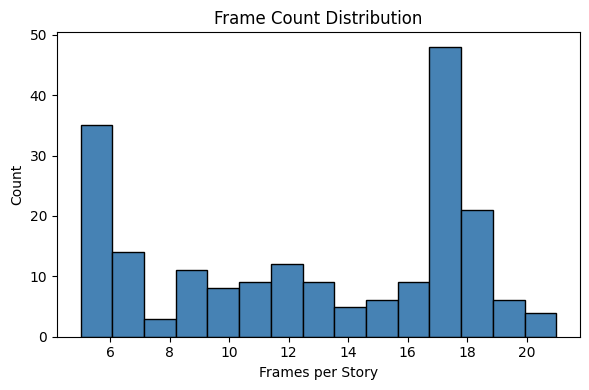

Min: 5 | Max: 21 | Mean: 12.7 | Median: 13.0


In [54]:
# Plotting frame count distribution
frame_counts = [ds["train"][i]["frame_count"] for i in range(200)]
plt.figure(figsize=(6, 4))
plt.hist(frame_counts, bins=15, color="steelblue", edgecolor="black")
plt.title("Frame Count Distribution")
plt.xlabel("Frames per Story")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/eda_frame_distribution.png")
plt.show()
print(f"Min: {min(frame_counts)} | Max: {max(frame_counts)} | Mean: {np.mean(frame_counts):.1f} | Median: {np.median(frame_counts):.1f}")

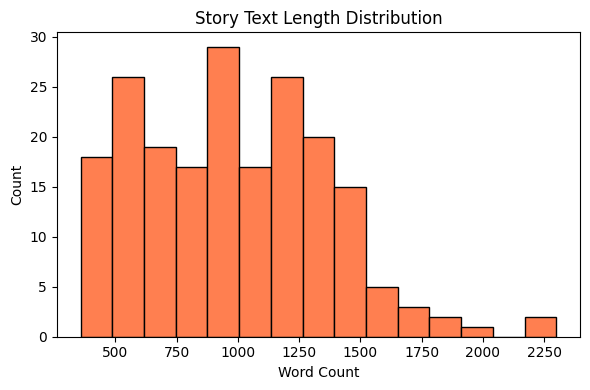

Min: 359 | Max: 2299 | Mean: 980.6 | Median: 968.5


In [55]:
# Plotting story text length distribution
text_lengths = [len(clean_story_text(ds["train"][i]["story"]).split()) for i in range(200)]
plt.figure(figsize=(6, 4))
plt.hist(text_lengths, bins=15, color="coral", edgecolor="black")
plt.title("Story Text Length Distribution")
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/eda_text_length_distribution.png")
plt.show()
print(f"Min: {min(text_lengths)} | Max: {max(text_lengths)} | Mean: {np.mean(text_lengths):.1f} | Median: {np.median(text_lengths):.1f}")

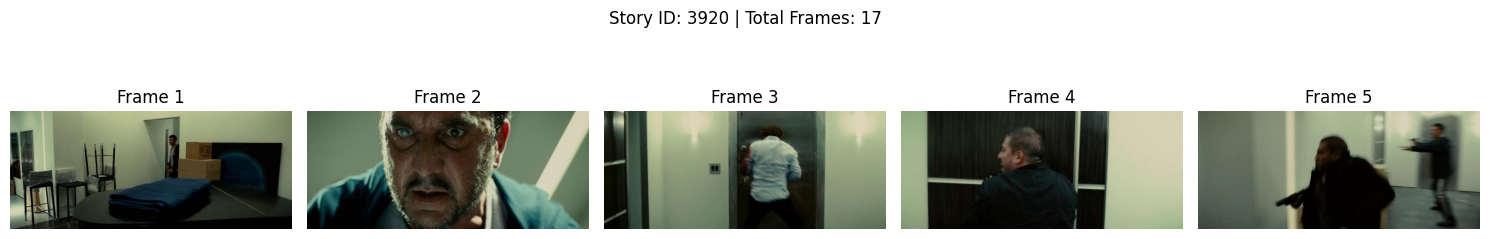

In [56]:
# Visualising sample story frames
sample = ds["train"][0]
n_show = min(5, sample["frame_count"])
fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
for i in range(n_show):
    axes[i].imshow(sample["images"][i])
    axes[i].set_title(f"Frame {i+1}")
    axes[i].axis("off")
plt.suptitle(f"Story ID: {sample['story_id']} | Total Frames: {sample['frame_count']}")
plt.tight_layout()
plt.savefig("results/eda_sample_story_frames.png")
plt.show()

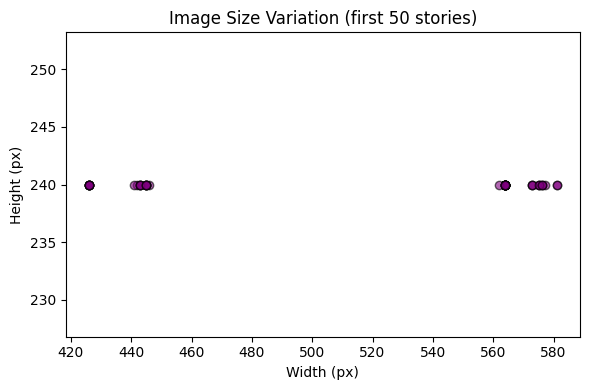

Width  — Min: 426, Max: 581, Mean: 513.5
Height — Min: 240, Max: 240, Mean: 240.0


In [57]:
# Checking image size variation
sizes   = [ds["train"][i]["images"][0].size for i in range(50)]
widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
plt.figure(figsize=(6, 4))
plt.scatter(widths, heights, alpha=0.6, color="purple", edgecolors="black")
plt.title("Image Size Variation (first 50 stories)")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.tight_layout()
plt.savefig("results/eda_image_size_variation.png")
plt.show()
print(f"Width  — Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.1f}")
print(f"Height — Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.1f}")

In [58]:
# Previewing cleaned story text
sample     = ds["train"][0]
raw_text   = sample["story"]
clean_text = clean_story_text(raw_text)
print("RAW (first 300 chars)")
print(raw_text[:300])
print("\nCleaned (first 300 chars)")
print(clean_text[:300])

RAW (first 300 chars)
<gdi image1>
In the sterile environment of a sparse room filled with <gdo obj1>cardboard boxes</gdo>, <gdo obj5>a blue blanket</gdo>, and <gdo bg26>a table</gdo>, <gdo char1>James</gdo> <gda char1>enters</gda> with a neutral look. His face reflects the calm before the storm. <gdo char1>James</gdo> <

Cleaned (first 300 chars)
In the sterile environment of a sparse room filled with cardboard boxes, a blue blanket, and a table, James enters with a neutral look. His face reflects the calm before the storm. James enters an empty room that holds the remnants of what looks like a hastily abandoned office. The room's neutral li


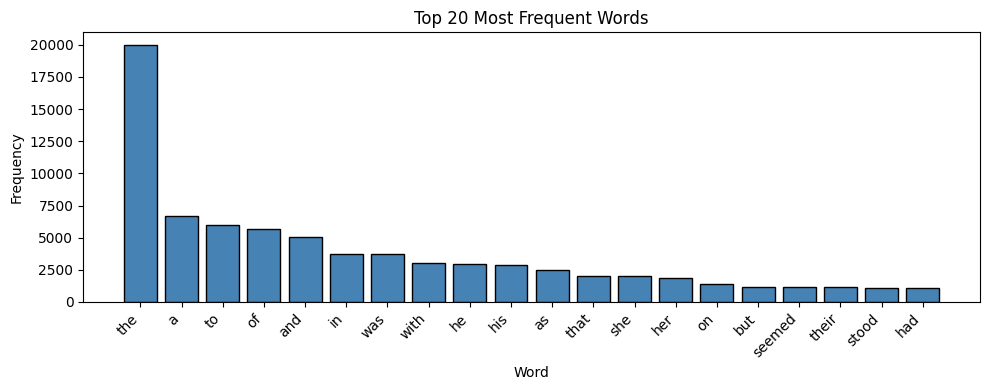

In [59]:
# Plotting top 20 most frequent words
all_words = []
for i in range(200):
    all_words.extend(clean_story_text(ds["train"][i]["story"]).lower().split())
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)
plt.figure(figsize=(10, 4))
plt.bar(words, freqs, color="steelblue", edgecolor="black")
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("results/eda_word_frequency.png")
plt.show()

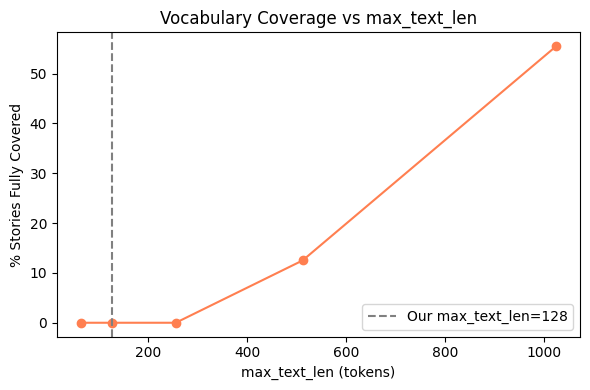

  max_text_len=  64 -- 0.0% stories fully covered
  max_text_len= 128 -- 0.0% stories fully covered
  max_text_len= 256 -- 0.0% stories fully covered
  max_text_len= 512 -- 12.5% stories fully covered
  max_text_len=1024 -- 55.5% stories fully covered


In [60]:
# Plotting vocabulary coverage at different max_text_len values
thresholds = [64, 128, 256, 512, 1024]
coverages  = []
for thresh in thresholds:
    covered = sum(1 for l in text_lengths if l <= thresh)
    coverages.append(covered / len(text_lengths) * 100)
plt.figure(figsize=(6, 4))
plt.plot(thresholds, coverages, marker="o", color="coral")
plt.axvline(x=128, color="gray", linestyle="--", label="Our max_text_len=128")
plt.title("Vocabulary Coverage vs max_text_len")
plt.xlabel("max_text_len (tokens)")
plt.ylabel("% Stories Fully Covered")
plt.legend()
plt.tight_layout()
plt.savefig("results/eda_vocab_coverage.png")
plt.show()
for t, c in zip(thresholds, coverages):
    print(f"  max_text_len={t:4d} -- {c:.1f}% stories fully covered")

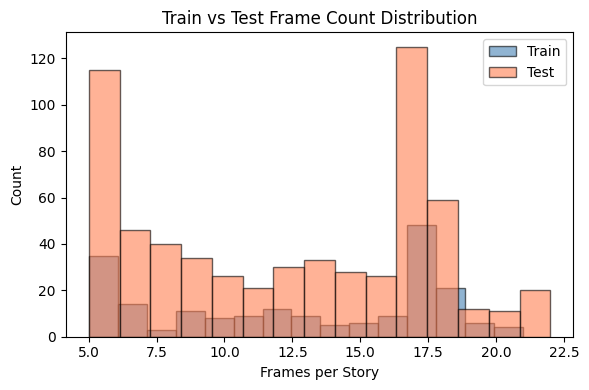

Train — Mean: 12.7 | Std: 4.9
Test  — Mean: 12.4 | Std: 5.1


In [61]:
# Comparing train vs test frame count distributions
train_frames = [ds["train"][i]["frame_count"] for i in range(200)]
test_frames  = [ds["test"][i]["frame_count"] for i in range(len(ds["test"]))]

plt.figure(figsize=(6, 4))
plt.hist(train_frames, bins=15, alpha=0.6, color="steelblue", edgecolor="black", label="Train")
plt.hist(test_frames,  bins=15, alpha=0.6, color="coral",     edgecolor="black", label="Test")
plt.title("Train vs Test Frame Count Distribution")
plt.xlabel("Frames per Story")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("results/eda_train_vs_test.png")
plt.show()

print(f"Train — Mean: {np.mean(train_frames):.1f} | Std: {np.std(train_frames):.1f}")
print(f"Test  — Mean: {np.mean(test_frames):.1f} | Std: {np.std(test_frames):.1f}")

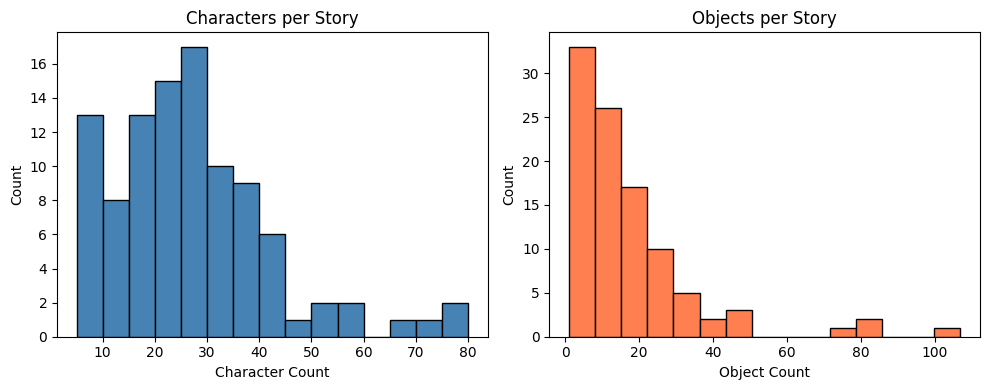

Characters — Mean: 26.7 | Max: 80
Objects    — Mean: 18.0 | Max: 107


In [62]:
# Analysing characters and objects per frame from CoT
char_counts = []
obj_counts  = []
for i in range(100):
    cot = ds["train"][i]["chain_of_thought"]
    chars = len(re.findall(r'\| char\d+', cot))
    objs  = len(re.findall(r'\| obj\d+',  cot))
    char_counts.append(chars)
    obj_counts.append(objs)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(char_counts, bins=15, color="steelblue", edgecolor="black")
plt.title("Characters per Story")
plt.xlabel("Character Count")
plt.ylabel("Count")
plt.subplot(1, 2, 2)
plt.hist(obj_counts, bins=15, color="coral", edgecolor="black")
plt.title("Objects per Story")
plt.xlabel("Object Count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/eda_chars_objects_per_story.png")
plt.show()
print(f"Characters — Mean: {np.mean(char_counts):.1f} | Max: {max(char_counts)}")
print(f"Objects    — Mean: {np.mean(obj_counts):.1f} | Max: {max(obj_counts)}")

In [63]:
# Updating max_text_len to 512 based on EDA findings
config["max_text_len"] = 512
with open("config.yaml", "w") as f:
    yaml.dump(config, f)
print("max_text_len updated to:", config["max_text_len"])

max_text_len updated to: 512


#PREPROCESSING

In [64]:
# Defining image transform pipeline
image_transform = transforms.Compose([
    transforms.Resize((config["image_size"], config["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
print("Image transform pipeline defined")

Image transform pipeline defined


In [65]:
# Building vocabulary from training stories
def build_vocab(dataset, min_freq=2):
    counter = Counter()
    for sample in dataset:
        tokens = clean_story_text(sample["story"]).lower().split()
        counter.update(tokens)
    vocab = {"<pad>": 0, "<unk>": 1, "<sos>": 2, "<eos>": 3}
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab
subset = ds["train"].select(range(config["subset_size"]))
vocab  = build_vocab(subset)
print(f"Vocabulary size: {len(vocab)}")
print(f"Sample tokens: {list(vocab.items())[:10]}")

Vocabulary size: 9196
Sample tokens: [('<pad>', 0), ('<unk>', 1), ('<sos>', 2), ('<eos>', 3), ('in', 4), ('the', 5), ('sterile', 6), ('environment', 7), ('of', 8), ('a', 9)]


In [66]:
# Encoding text to fixed-length tensor
def encode_text(text, vocab, max_len):
    tokens = clean_story_text(text).lower().split()
    ids    = [vocab.get(t, vocab["<unk>"]) for t in tokens[:max_len]]
    ids    = [vocab["<sos>"]] + ids + [vocab["<eos>"]]
    if len(ids) < max_len + 2:
        ids += [vocab["<pad>"]] * (max_len + 2 - len(ids))
    return torch.tensor(ids[:max_len + 2], dtype=torch.long)

# Testing encoding
sample_text   = clean_story_text(ds["train"][0]["story"])
encoded       = encode_text(sample_text, vocab, config["max_text_len"])
print(f"Encoded text shape: {encoded.shape}")
print(f"First 10 token ids: {encoded[:10].tolist()}")

Encoded text shape: torch.Size([514])
First 10 token ids: [2, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [67]:
# Defining PyTorch Dataset for StoryReasoning
class StoryDataset(Dataset):
    def __init__(self, hf_dataset, vocab, config):
        self.data   = hf_dataset
        self.vocab  = vocab
        self.config = config
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sample = self.data[idx]
        images = sample["images"]
        K      = len(images) - 1
        input_images = torch.stack([
            image_transform(img.convert("RGB")) for img in images[:K]
        ])
        target_image = image_transform(images[K].convert("RGB"))
        text_tensor  = encode_text(sample["story"], self.vocab, self.config["max_text_len"])
        return {
            "input_images": input_images,    # (K, 3, 224, 224)
            "target_image": target_image,    # (3, 224, 224)
            "text":         text_tensor,     # (max_text_len+2,)
            "frame_count":  K,
        }
print("StoryDataset class defined")

StoryDataset class defined


In [68]:
# Splitting subset into train, val, test
n       = len(subset)
n_train = int(n * config["train_split"])
n_val   = int(n * config["val_split"])
train_ds = StoryDataset(subset.select(range(n_train)), vocab, config)
val_ds   = StoryDataset(subset.select(range(n_train, n_train + n_val)), vocab, config)
test_ds  = StoryDataset(subset.select(range(n_train + n_val, n)), vocab, config)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
# Verifying one sample
sample = train_ds[0]
print(f"\nInput images shape: {sample['input_images'].shape}")
print(f"Target image shape: {sample['target_image'].shape}")
print(f"Text tensor shape:  {sample['text'].shape}")
print(f"Frame count (K):    {sample['frame_count']}")

Train: 400 | Val: 50 | Test: 50

Input images shape: torch.Size([16, 3, 224, 224])
Target image shape: torch.Size([3, 224, 224])
Text tensor shape:  torch.Size([514])
Frame count (K):    16


# VISUAL ENCODER


In [69]:
class VisualEncoder(nn.Module):
    def __init__(self, hidden_dim):
        super(VisualEncoder, self).__init__()
        # Loading pretrained ResNet18 as CNN backbone
        resnet        = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.project  = nn.Linear(512, hidden_dim)
        self.relu     = nn.ReLU()
    def forward(self, x):
        # x: (batch, K, 3, 224, 224)
        batch, K, C, H, W = x.shape
        x = x.view(batch * K, C, H, W)
        with torch.no_grad():
            features = self.backbone(x)
        features = features.view(batch * K, -1)
        features = self.relu(self.project(features))
        features = features.view(batch, K, -1)
        return features   # (batch, K, hidden_dim)
# Testing visual encoder
visual_encoder = VisualEncoder(config["hidden_dim"]).to(device)
dummy_images   = torch.randn(2, 5, 3, 224, 224).to(device)
output         = visual_encoder(dummy_images)
print(f"Visual encoder output shape: {output.shape}")
print(f"Expected: (2, 5, {config['hidden_dim']})")

Visual encoder output shape: torch.Size([2, 5, 256])
Expected: (2, 5, 256)



#TEXT ENCODER



In [70]:
class TextEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(TextEncoder, self).__init__()
        # Embedding and LSTM layers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm      = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )
        self.project   = nn.Linear(hidden_dim, hidden_dim)
        self.relu      = nn.ReLU()
    def forward(self, x):
        # x: (batch, seq_len)
        embedded        = self.embedding(x)
        _, (hidden, _)  = self.lstm(embedded)
        features        = self.relu(self.project(hidden[-1]))
        return features  # (batch, hidden_dim)
# Testing text encoder
text_encoder = TextEncoder(
    vocab_size = len(vocab),
    embed_dim  = config["embed_dim"],
    hidden_dim = config["hidden_dim"],
    num_layers = config["num_layers"],
    dropout    = config["dropout"],
).to(device)
dummy_text = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
output     = text_encoder(dummy_text)
print(f"Text encoder output shape: {output.shape}")
print(f"Expected: (2, {config['hidden_dim']})")

Text encoder output shape: torch.Size([2, 256])
Expected: (2, 256)



# MULTIMODAL FUSION (BASELINE)



In [71]:
class BaselineFusion(nn.Module):
    def __init__(self, hidden_dim):
        super(BaselineFusion, self).__init__()
        # Projecting concatenated features back to hidden_dim
        self.project = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu    = nn.ReLU()
    def forward(self, visual_features, text_features):
        # visual_features: (batch, K, hidden_dim)
        # text_features:   (batch, hidden_dim)
        # Expanding text features to match sequence length
        text_expanded = text_features.unsqueeze(1).expand(-1, visual_features.size(1), -1)
        # Concatenating visual and text features
        fused  = torch.cat([visual_features, text_expanded], dim=-1)
        output = self.relu(self.project(fused))
        return output   # (batch, K, hidden_dim)
# Testing baseline fusion
baseline_fusion = BaselineFusion(config["hidden_dim"]).to(device)
dummy_visual = torch.randn(2, 5, config["hidden_dim"]).to(device)
dummy_text   = torch.randn(2, config["hidden_dim"]).to(device)
output       = baseline_fusion(dummy_visual, dummy_text)
print(f"Baseline fusion output shape: {output.shape}")
print(f"Expected: (2, 5, {config['hidden_dim']})")

Baseline fusion output shape: torch.Size([2, 5, 256])
Expected: (2, 5, 256)



#SEQUENCE MODEL (BASELINE LSTM)


In [72]:
class SequenceModel(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout):
        super(SequenceModel, self).__init__()
        # Standard LSTM for temporal modeling
        self.lstm = nn.LSTM(
            hidden_dim,
            hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )
    def forward(self, x):
        # x: (batch, K, hidden_dim)
        output, (hidden, _) = self.lstm(x)
        return output, hidden[-1]   # (batch, K, hidden_dim), (batch, hidden_dim)
# Testing sequence model
sequence_model = SequenceModel(
    hidden_dim = config["hidden_dim"],
    num_layers = config["num_layers"],
    dropout    = config["dropout"],
).to(device)
dummy_input        = torch.randn(2, 5, config["hidden_dim"]).to(device)
seq_out, last_hidden = sequence_model(dummy_input)
print(f"Sequence output shape:   {seq_out.shape}")
print(f"Last hidden state shape: {last_hidden.shape}")
print(f"Expected: (2, 5, {config['hidden_dim']}) and (2, {config['hidden_dim']})")

Sequence output shape:   torch.Size([2, 5, 256])
Last hidden state shape: torch.Size([2, 256])
Expected: (2, 5, 256) and (2, 256)



# ATTENTION MECHANISM (BASELINE)


In [73]:
class AttentionMechanism(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionMechanism, self).__init__()
        # Dot-product attention scoring
        self.attention = nn.Linear(hidden_dim, 1)
    def forward(self, sequence_output):
        # sequence_output: (batch, K, hidden_dim)
        # Computing attention scores and weights
        scores  = self.attention(sequence_output)          # (batch, K, 1)
        weights = torch.softmax(scores, dim=1)             # (batch, K, 1)
        # Computing weighted context vector
        context = (weights * sequence_output).sum(dim=1)  # (batch, hidden_dim)
        return context, weights.squeeze(-1)                # (batch, hidden_dim), (batch, K)
# Testing attention mechanism
attention = AttentionMechanism(config["hidden_dim"]).to(device)
dummy_seq          = torch.randn(2, 5, config["hidden_dim"]).to(device)
context, weights   = attention(dummy_seq)
print(f"Context vector shape:    {context.shape}")
print(f"Attention weights shape: {weights.shape}")
print(f"Expected: (2, {config['hidden_dim']}) and (2, 5)")
print(f"Weights sum (should be 1.0): {weights[0].sum().item():.4f}")

Context vector shape:    torch.Size([2, 256])
Attention weights shape: torch.Size([2, 5])
Expected: (2, 256) and (2, 5)
Weights sum (should be 1.0): 1.0000



# IMAGE DECODER


In [74]:
class ImageDecoder(nn.Module):
    def __init__(self, hidden_dim):
        super(ImageDecoder, self).__init__()
        # Projecting context vector to image space
        self.fc = nn.Linear(hidden_dim, 256 * 7 * 7)
        # Upsampling via transposed convolutions
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )
    def forward(self, context):
        # context: (batch, hidden_dim)
        x = self.fc(context)
        x = x.view(x.size(0), 256, 7, 7)
        x = self.decoder(x)
        return x   # (batch, 3, 224, 224)
# Testing image decoder
image_decoder = ImageDecoder(config["hidden_dim"]).to(device)
dummy_context = torch.randn(2, config["hidden_dim"]).to(device)
output        = image_decoder(dummy_context)
print(f"Image decoder output shape: {output.shape}")
print(f"Expected: (2, 3, 224, 224)")
print(f"Output range: [{output.min().item():.2f}, {output.max().item():.2f}] (Tanh: -1 to 1)")

Image decoder output shape: torch.Size([2, 3, 224, 224])
Expected: (2, 3, 224, 224)
Output range: [-0.11, 0.13] (Tanh: -1 to 1)



# TEXT DECODER


In [75]:
class TextDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(TextDecoder, self).__init__()
        # Embedding, LSTM and output projection
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(
            embed_dim + hidden_dim,
            hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )
        self.project    = nn.Linear(hidden_dim, vocab_size)
    def forward(self, context, target_text):
        # context:     (batch, hidden_dim)
        # target_text: (batch, seq_len)
        embedded      = self.embedding(target_text)
        context_exp   = context.unsqueeze(1).expand(-1, embedded.size(1), -1)
        # Concatenating context with embeddings at each timestep
        lstm_input    = torch.cat([embedded, context_exp], dim=-1)
        output, _     = self.lstm(lstm_input)
        logits        = self.project(output)
        return logits   # (batch, seq_len, vocab_size)
# Testing text decoder
text_decoder = TextDecoder(
    vocab_size = len(vocab),
    embed_dim  = config["embed_dim"],
    hidden_dim = config["hidden_dim"],
    num_layers = config["num_layers"],
    dropout    = config["dropout"],
).to(device)
dummy_context = torch.randn(2, config["hidden_dim"]).to(device)
dummy_text    = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
output        = text_decoder(dummy_context, dummy_text)
print(f"Text decoder output shape: {output.shape}")
print(f"Expected: (2, {config['max_text_len'] + 2}, {len(vocab)})")

Text decoder output shape: torch.Size([2, 514, 9196])
Expected: (2, 514, 9196)



# FULL BASELINE MODEL


In [76]:
class BaselineModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(BaselineModel, self).__init__()
        # Assembling all components
        self.visual_encoder  = VisualEncoder(hidden_dim)
        self.text_encoder    = TextEncoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)
        self.fusion          = BaselineFusion(hidden_dim)
        self.sequence_model  = SequenceModel(hidden_dim, num_layers, dropout)
        self.attention       = AttentionMechanism(hidden_dim)
        self.image_decoder   = ImageDecoder(hidden_dim)
        self.text_decoder    = TextDecoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)
    def forward(self, input_images, text, target_text):
        # Encoding inputs
        visual_features  = self.visual_encoder(input_images)
        text_features    = self.text_encoder(text)
        # Fusing modalities
        fused            = self.fusion(visual_features, text_features)
        # Modeling temporal sequence
        seq_out, _       = self.sequence_model(fused)
        # Applying attention
        context, weights = self.attention(seq_out)
        # Decoding outputs
        image_pred       = self.image_decoder(context)
        text_pred        = self.text_decoder(context, target_text)
        return image_pred, text_pred, weights
# Instantiating baseline model
baseline_model = BaselineModel(
    vocab_size = len(vocab),
    embed_dim  = config["embed_dim"],
    hidden_dim = config["hidden_dim"],
    num_layers = config["num_layers"],
    dropout    = config["dropout"],
).to(device)
# Counting parameters
total_params = sum(p.numel() for p in baseline_model.parameters())
print(f"Total parameters: {total_params:,}")
# Running full forward pass
dummy_images      = torch.randn(2, 5, 3, 224, 224).to(device)
dummy_text        = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
dummy_target_text = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
image_pred, text_pred, attn_weights = baseline_model(dummy_images, dummy_text, dummy_target_text)
print(f"Image prediction shape:   {image_pred.shape}")
print(f"Text prediction shape:    {text_pred.shape}")
print(f"Attention weights shape:  {attn_weights.shape}")

Total parameters: 23,301,920
Image prediction shape:   torch.Size([2, 3, 224, 224])
Text prediction shape:    torch.Size([2, 514, 9196])
Attention weights shape:  torch.Size([2, 5])


In [77]:
#TRAINING BASELINE MODEL
# Collating variable-length sequences
def collate_fn(batch):
    max_frames = max(b["frame_count"] for b in batch)
    B          = len(batch)
    C, H, W    = 3, config["image_size"], config["image_size"]
    padded_images = torch.zeros(B, max_frames, C, H, W)
    target_images = torch.zeros(B, C, H, W)
    texts         = torch.zeros(B, config["max_text_len"] + 2, dtype=torch.long)
    frame_counts  = []
    for i, b in enumerate(batch):
        K = b["frame_count"]
        padded_images[i, :K] = b["input_images"]
        target_images[i]     = b["target_image"]
        texts[i]             = b["text"]
        frame_counts.append(K)
    return {
        "input_images": padded_images,
        "target_image": target_images,
        "text":         texts,
        "frame_counts": frame_counts, }
# Creating dataloaders
train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False, collate_fn=collate_fn)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
# Defining loss functions
image_loss_fn = nn.MSELoss()
text_loss_fn  = nn.CrossEntropyLoss(ignore_index=0)
print("Loss functions defined")

Train batches: 50
Val batches:   7
Loss functions defined


In [78]:
# Training and validating baseline model
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=config["learning_rate"])
train_losses = []
val_losses   = []
for epoch in range(config["num_epochs"]):
    baseline_model.train()
    epoch_loss = 0
    for batch in train_loader:
        input_images  = batch["input_images"].to(device)
        target_images = batch["target_image"].to(device)
        texts         = batch["text"].to(device)
        optimizer.zero_grad()
        image_pred, text_pred, _ = baseline_model(input_images, texts, texts)
        img_loss  = image_loss_fn(image_pred, target_images)
        txt_loss  = text_loss_fn(text_pred.view(-1, len(vocab)), texts.view(-1))
        loss      = img_loss + txt_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(baseline_model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validating
    baseline_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_images  = batch["input_images"].to(device)
            target_images = batch["target_image"].to(device)
            texts         = batch["text"].to(device)
            image_pred, text_pred, _ = baseline_model(input_images, texts, texts)
            img_loss  = image_loss_fn(image_pred, target_images)
            txt_loss  = text_loss_fn(text_pred.view(-1, len(vocab)), texts.view(-1))
            val_loss += (img_loss + txt_loss).item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{config['num_epochs']} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/20 | Train Loss: 7.9786 | Val Loss: 7.2574
Epoch 2/20 | Train Loss: 6.9697 | Val Loss: 6.7707
Epoch 3/20 | Train Loss: 6.3249 | Val Loss: 5.9545
Epoch 4/20 | Train Loss: 5.4591 | Val Loss: 5.1133
Epoch 5/20 | Train Loss: 4.7259 | Val Loss: 4.4611
Epoch 6/20 | Train Loss: 4.1146 | Val Loss: 3.8929
Epoch 7/20 | Train Loss: 3.5899 | Val Loss: 3.4188
Epoch 8/20 | Train Loss: 3.1632 | Val Loss: 3.0417
Epoch 9/20 | Train Loss: 2.8147 | Val Loss: 2.7400
Epoch 10/20 | Train Loss: 2.5337 | Val Loss: 2.4986
Epoch 11/20 | Train Loss: 2.3035 | Val Loss: 2.3034
Epoch 12/20 | Train Loss: 2.1112 | Val Loss: 2.1422
Epoch 13/20 | Train Loss: 1.9479 | Val Loss: 2.0056
Epoch 14/20 | Train Loss: 1.8076 | Val Loss: 1.8932
Epoch 15/20 | Train Loss: 1.6877 | Val Loss: 1.7957
Epoch 16/20 | Train Loss: 1.5838 | Val Loss: 1.7126
Epoch 17/20 | Train Loss: 1.4935 | Val Loss: 1.6392
Epoch 18/20 | Train Loss: 1.4140 | Val Loss: 1.5783
Epoch 19/20 | Train Loss: 1.3450 | Val Loss: 1.5233
Epoch 20/20 | Train L

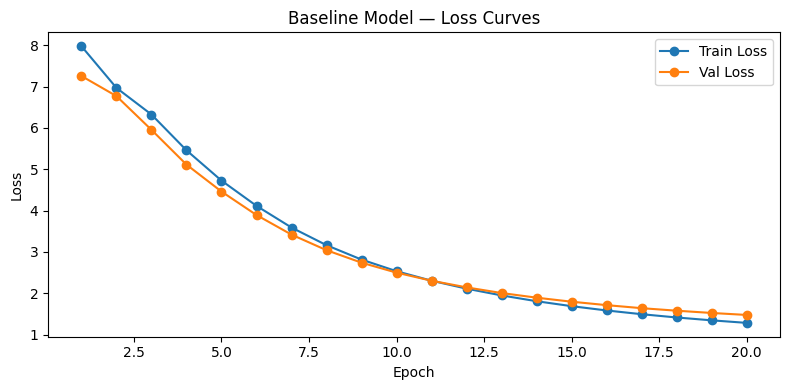

Best Train Loss: 1.2834
Best Val Loss:   1.4753


In [79]:
# Plotting training and validation loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, config["num_epochs"] + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, config["num_epochs"] + 1), val_losses,   label="Val Loss",   marker="o")
plt.title("Baseline Model — Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/baseline_loss_curves.png")
plt.show()
print(f"Best Train Loss: {min(train_losses):.4f}")
print(f"Best Val Loss:   {min(val_losses):.4f}")


# CROSS-MODAL ATTENTION FUSION


In [80]:
class CrossModalAttentionFusion(nn.Module):
    def __init__(self, hidden_dim):
        super(CrossModalAttentionFusion, self).__init__()
        # Image attending to text
        self.visual_query = nn.Linear(hidden_dim, hidden_dim)
        self.text_key     = nn.Linear(hidden_dim, hidden_dim)
        self.text_value   = nn.Linear(hidden_dim, hidden_dim)
        # Text attending to image
        self.text_query   = nn.Linear(hidden_dim, hidden_dim)
        self.visual_key   = nn.Linear(hidden_dim, hidden_dim)
        self.visual_value = nn.Linear(hidden_dim, hidden_dim)
        # Projecting fused output back to hidden_dim
        self.project      = nn.Linear(hidden_dim * 2, hidden_dim)
        self.relu         = nn.ReLU()
        self.scale        = hidden_dim ** 0.5
    def forward(self, visual_features, text_features):
        # visual_features: (batch, K, hidden_dim)
        # text_features:   (batch, hidden_dim)
        text_exp = text_features.unsqueeze(1)   # (batch, 1, hidden_dim)
        # Visual queries attending to text
        V_q      = self.visual_query(visual_features)
        T_k      = self.text_key(text_exp)
        T_v      = self.text_value(text_exp)
        v_scores = torch.bmm(V_q, T_k.transpose(1, 2)) / self.scale
        v_attn   = torch.softmax(v_scores, dim=-1)
        v_ctx    = torch.bmm(v_attn, T_v)              # (batch, K, hidden_dim)
        # Text queries attending to visual
        T_q      = self.text_query(text_exp)
        V_k      = self.visual_key(visual_features)
        V_v      = self.visual_value(visual_features)
        t_scores = torch.bmm(T_q, V_k.transpose(1, 2)) / self.scale
        t_attn   = torch.softmax(t_scores, dim=-1)
        t_ctx    = torch.bmm(t_attn, V_v)              # (batch, 1, hidden_dim)
        t_ctx    = t_ctx.expand(-1, visual_features.size(1), -1)
        # Fusing both attended representations
        fused    = torch.cat([v_ctx, t_ctx], dim=-1)
        output   = self.relu(self.project(fused))
        return output   # (batch, K, hidden_dim)
# Testing cross-modal attention fusion
cross_modal_fusion = CrossModalAttentionFusion(config["hidden_dim"]).to(device)
dummy_visual = torch.randn(2, 5, config["hidden_dim"]).to(device)
dummy_text   = torch.randn(2, config["hidden_dim"]).to(device)
output       = cross_modal_fusion(dummy_visual, dummy_text)
print(f"Cross-modal fusion output shape: {output.shape}")
print(f"Expected: (2, 5, {config['hidden_dim']})")

Cross-modal fusion output shape: torch.Size([2, 5, 256])
Expected: (2, 5, 256)



#BIDIRECTIONAL LSTM



In [81]:
class BidirectionalSequenceModel(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout):
        super(BidirectionalSequenceModel, self).__init__()
        # BiLSTM reads sequence in both directions
        self.bilstm  = nn.LSTM(
            hidden_dim,
            hidden_dim // 2,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
            bidirectional = True,
        )
        # Projecting concatenated forward and backward states
        self.project = nn.Linear(hidden_dim, hidden_dim)
        self.relu    = nn.ReLU()
    def forward(self, x):
        # x: (batch, K, hidden_dim)
        output, (hidden, _) = self.bilstm(x)
        # Concatenating last forward and backward hidden states
        forward_h  = hidden[-2]
        backward_h = hidden[-1]
        last_hidden = self.relu(self.project(
            torch.cat([forward_h, backward_h], dim=-1)
        ))
        return output, last_hidden   # (batch, K, hidden_dim), (batch, hidden_dim)
# Testing bidirectional sequence model
bilstm_model = BidirectionalSequenceModel(
    hidden_dim = config["hidden_dim"],
    num_layers = config["num_layers"],
    dropout    = config["dropout"],
).to(device)
dummy_input        = torch.randn(2, 5, config["hidden_dim"]).to(device)
seq_out, last_hidden = bilstm_model(dummy_input)
print(f"BiLSTM sequence output shape:   {seq_out.shape}")
print(f"BiLSTM last hidden state shape: {last_hidden.shape}")
print(f"Expected: (2, 5, {config['hidden_dim']}) and (2, {config['hidden_dim']})")

BiLSTM sequence output shape:   torch.Size([2, 5, 256])
BiLSTM last hidden state shape: torch.Size([2, 256])
Expected: (2, 5, 256) and (2, 256)



#MULTI-TASK LOSS



In [82]:
class MultiTaskLoss(nn.Module):
    def __init__(self):
        super(MultiTaskLoss, self).__init__()
        # Learnable weights for balancing image and text losses
        self.log_var_image = nn.Parameter(torch.zeros(1))
        self.log_var_text  = nn.Parameter(torch.zeros(1))
        self.image_loss_fn = nn.MSELoss()
        self.text_loss_fn  = nn.CrossEntropyLoss(ignore_index=0)
    def forward(self, image_pred, image_target, text_pred, text_target):
        # Computing individual losses
        image_loss = self.image_loss_fn(image_pred, image_target)
        text_loss  = self.text_loss_fn(
            text_pred.view(-1, text_pred.size(-1)),
            text_target.view(-1)
        )
        # Weighting losses using learned uncertainty
        weighted_image = torch.exp(-self.log_var_image) * image_loss + self.log_var_image
        weighted_text  = torch.exp(-self.log_var_text)  * text_loss  + self.log_var_text
        total_loss = weighted_image + weighted_text
        return total_loss, image_loss.item(), text_loss.item()
# Testing multi-task loss
multitask_loss = MultiTaskLoss().to(device)
dummy_image_pred   = torch.randn(2, 3, 224, 224).to(device)
dummy_image_target = torch.randn(2, 3, 224, 224).to(device)
dummy_text_pred    = torch.randn(2, config["max_text_len"] + 2, len(vocab)).to(device)
dummy_text_target  = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
total, img_l, txt_l = multitask_loss(
    dummy_image_pred, dummy_image_target,
    dummy_text_pred,  dummy_text_target
)
print(f"Total loss:  {total.item():.4f}")
print(f"Image loss:  {img_l:.4f}")
print(f"Text loss:   {txt_l:.4f}")
print(f"Log var image (learnable): {multitask_loss.log_var_image.item():.4f}")
print(f"Log var text  (learnable): {multitask_loss.log_var_text.item():.4f}")

Total loss:  11.6341
Image loss:  2.0092
Text loss:   9.6249
Log var image (learnable): 0.0000
Log var text  (learnable): 0.0000



#FULL INNOVATION MODEL


In [83]:
class InnovationModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super(InnovationModel, self).__init__()
        # Assembling all components with innovations
        self.visual_encoder  = VisualEncoder(hidden_dim)
        self.text_encoder    = TextEncoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)
        self.fusion          = CrossModalAttentionFusion(hidden_dim)   # Innovation 1
        self.sequence_model  = BidirectionalSequenceModel(hidden_dim, num_layers, dropout)  # Innovation 2
        self.attention       = AttentionMechanism(hidden_dim)
        self.image_decoder   = ImageDecoder(hidden_dim)
        self.text_decoder    = TextDecoder(vocab_size, embed_dim, hidden_dim, num_layers, dropout)
    def forward(self, input_images, text, target_text):
        # Encoding inputs
        visual_features  = self.visual_encoder(input_images)
        text_features    = self.text_encoder(text)
        # Fusing modalities with cross-modal attention
        fused            = self.fusion(visual_features, text_features)
        # Modeling temporal sequence with BiLSTM
        seq_out, _       = self.sequence_model(fused)
        # Applying attention
        context, weights = self.attention(seq_out)
        # Decoding outputs
        image_pred       = self.image_decoder(context)
        text_pred        = self.text_decoder(context, target_text)
        return image_pred, text_pred, weights
# Instantiating innovation model
innovation_model = InnovationModel(
    vocab_size = len(vocab),
    embed_dim  = config["embed_dim"],
    hidden_dim = config["hidden_dim"],
    num_layers = config["num_layers"],
    dropout    = config["dropout"],
).to(device)
# Counting parameters
total_params = sum(p.numel() for p in innovation_model.parameters())
print(f"Total parameters: {total_params:,}")
# Running full forward pass
dummy_images      = torch.randn(2, 5, 3, 224, 224).to(device)
dummy_text        = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
dummy_target_text = torch.randint(0, len(vocab), (2, config["max_text_len"] + 2)).to(device)
image_pred, text_pred, attn_weights = innovation_model(dummy_images, dummy_text, dummy_target_text)
print(f"Image prediction shape:  {image_pred.shape}")
print(f"Text prediction shape:   {text_pred.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

Total parameters: 23,500,320
Image prediction shape:  torch.Size([2, 3, 224, 224])
Text prediction shape:   torch.Size([2, 514, 9196])
Attention weights shape: torch.Size([2, 5])


In [84]:
#TRAINING INNOVATION MODEL
# Setting up optimizer with multi-task loss parameters
multitask_loss     = MultiTaskLoss().to(device)
innovation_params  = list(innovation_model.parameters()) + list(multitask_loss.parameters())
optimizer_inn      = torch.optim.Adam(innovation_params, lr=config["learning_rate"])
print("Innovation optimizer and multi-task loss ready")
print(f"Learnable loss weights included: log_var_image, log_var_text")

Innovation optimizer and multi-task loss ready
Learnable loss weights included: log_var_image, log_var_text


In [85]:
# Training and validating innovation model
inn_train_losses = []
inn_val_losses   = []
for epoch in range(config["num_epochs"]):
    innovation_model.train()
    multitask_loss.train()
    epoch_loss = 0
    for batch in train_loader:
        input_images  = batch["input_images"].to(device)
        target_images = batch["target_image"].to(device)
        texts         = batch["text"].to(device)
        optimizer_inn.zero_grad()
        image_pred, text_pred, _ = innovation_model(input_images, texts, texts)
        loss, img_l, txt_l = multitask_loss(image_pred, target_images, text_pred, texts)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(innovation_params, 1.0)
        optimizer_inn.step()
        epoch_loss += loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    inn_train_losses.append(avg_train_loss)

    # Validating
    innovation_model.eval()
    multitask_loss.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            input_images  = batch["input_images"].to(device)
            target_images = batch["target_image"].to(device)
            texts         = batch["text"].to(device)
            image_pred, text_pred, _ = innovation_model(input_images, texts, texts)
            loss, _, _    = multitask_loss(image_pred, target_images, text_pred, texts)
            val_loss     += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    inn_val_losses.append(avg_val_loss)
    print(f"Epoch {epoch+1}/{config['num_epochs']} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | log_var_img: {multitask_loss.log_var_image.item():.4f} | log_var_txt: {multitask_loss.log_var_text.item():.4f}")

Epoch 1/20 | Train Loss: 8.0398 | Val Loss: 7.1065 | log_var_img: 0.0194 | log_var_txt: 0.0501
Epoch 2/20 | Train Loss: 6.7914 | Val Loss: 6.5564 | log_var_img: -0.0007 | log_var_txt: 0.1012
Epoch 3/20 | Train Loss: 6.1935 | Val Loss: 5.9297 | log_var_img: -0.0243 | log_var_txt: 0.1519
Epoch 4/20 | Train Loss: 5.5156 | Val Loss: 5.1873 | log_var_img: -0.0485 | log_var_txt: 0.2024
Epoch 5/20 | Train Loss: 4.7434 | Val Loss: 4.3851 | log_var_img: -0.0699 | log_var_txt: 0.2527
Epoch 6/20 | Train Loss: 3.9714 | Val Loss: 3.6433 | log_var_img: -0.0896 | log_var_txt: 0.3027
Epoch 7/20 | Train Loss: 3.2634 | Val Loss: 2.9844 | log_var_img: -0.1118 | log_var_txt: 0.3510
Epoch 8/20 | Train Loss: 2.7035 | Val Loss: 2.5425 | log_var_img: -0.1267 | log_var_txt: 0.3806
Epoch 9/20 | Train Loss: 2.3473 | Val Loss: 2.2762 | log_var_img: -0.1318 | log_var_txt: 0.3898
Epoch 10/20 | Train Loss: 2.1077 | Val Loss: 2.0873 | log_var_img: -0.1303 | log_var_txt: 0.3841
Epoch 11/20 | Train Loss: 1.9267 | Val L

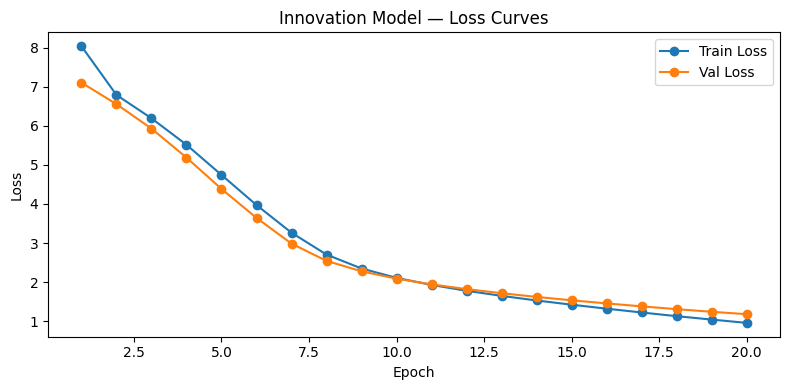

Best Train Loss: 0.9551
Best Val Loss:   1.1775


In [86]:
# Plotting innovation model loss curves
plt.figure(figsize=(8, 4))
plt.plot(range(1, config["num_epochs"] + 1), inn_train_losses, label="Train Loss", marker="o")
plt.plot(range(1, config["num_epochs"] + 1), inn_val_losses,   label="Val Loss",   marker="o")
plt.title("Innovation Model — Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/innovation_loss_curves.png")
plt.show()
print(f"Best Train Loss: {min(inn_train_losses):.4f}")
print(f"Best Val Loss:   {min(inn_val_losses):.4f}")


#EVALUATING AND COMPARING MODELS


In [87]:
nltk.download("punkt", quiet=True)
def compute_perplexity(text_pred, text_target):
    loss = text_loss_fn(text_pred.view(-1, len(vocab)), text_target.view(-1))
    return torch.exp(loss).item()
def evaluate_model_full(model, dataloader, multitask=False, loss_fn=None):
    model.eval()
    total_loss   = 0
    total_mse    = 0
    psnr_scores  = []
    ssim_scores  = []
    perplexities = []
    references   = []
    hypotheses   = []
    with torch.no_grad():
        for batch in dataloader:
            input_images  = batch["input_images"].to(device)
            target_images = batch["target_image"].to(device)
            texts         = batch["text"].to(device)
            image_pred, text_pred, _ = model(input_images, texts, texts)
            # Computing loss
            if multitask:
                loss, _, _ = loss_fn(image_pred, target_images, text_pred, texts)
            else:
                img_loss = image_loss_fn(image_pred, target_images)
                txt_loss = text_loss_fn(text_pred.view(-1, len(vocab)), texts.view(-1))
                loss     = img_loss + txt_loss
            total_loss += loss.item()
            # Computing MSE
            total_mse += nn.MSELoss()(image_pred, target_images).item()
            # Computing PSNR and SSIM
            pred_np   = image_pred.cpu().numpy().transpose(0, 2, 3, 1)
            target_np = target_images.cpu().numpy().transpose(0, 2, 3, 1)
            pred_np   = (pred_np   - pred_np.min())   / (pred_np.max()   - pred_np.min()   + 1e-8)
            target_np = (target_np - target_np.min()) / (target_np.max() - target_np.min() + 1e-8)

            for p, t in zip(pred_np, target_np):
                psnr_scores.append(psnr(t, p, data_range=1.0))
                ssim_scores.append(ssim(t, p, data_range=1.0, channel_axis=-1))
            # Computing perplexity
            perplexities.append(compute_perplexity(text_pred, texts))
            # Computing BLEU
            pred_ids = text_pred.argmax(dim=-1).cpu().tolist()
            ref_ids  = texts.cpu().tolist()
            for ref, hyp in zip(ref_ids, pred_ids):
                references.append([ref])
                hypotheses.append(hyp)
    # Computing BLEU-4
    smoother  = SmoothingFunction().method1
    bleu      = corpus_bleu(references, hypotheses, smoothing_function=smoother)
    # Computing parameter efficiency
    return {
        "loss":        total_loss  / len(dataloader),
        "mse":         total_mse   / len(dataloader),
        "psnr":        np.mean(psnr_scores),
        "ssim":        np.mean(ssim_scores),
        "perplexity":  np.mean(perplexities),
        "bleu":        bleu,
    }
print("Evaluation function defined")

Evaluation function defined


In [88]:
# Evaluating both models on validation set
print("Evaluating baseline model...")
baseline_results   = evaluate_model_full(baseline_model,   val_loader)
print("Evaluating innovation model...")
innovation_results = evaluate_model_full(innovation_model, val_loader, multitask=True, loss_fn=multitask_loss)
# Computing parameter efficiency
baseline_params    = sum(p.numel() for p in baseline_model.parameters())
innovation_params  = sum(p.numel() for p in innovation_model.parameters())
extra_params       = innovation_params - baseline_params
loss_improvement   = baseline_results["loss"] - innovation_results["loss"]
param_efficiency   = loss_improvement / (extra_params / 1e6)
print("\nEvaluation Results")
print(f"{'Metric':<20} {'Baseline':>12} {'Innovation':>12} {'Better':>10}")
metrics_info = [
    ("Loss",        "loss",       "lower"),
    ("MSE",         "mse",        "lower"),
    ("PSNR",        "psnr",       "higher"),
    ("SSIM",        "ssim",       "higher"),
    ("Perplexity",  "perplexity", "lower"),
    ("BLEU-4",      "bleu",       "higher"),
]
for name, key, better in metrics_info:
    b = baseline_results[key]
    i = innovation_results[key]
    winner = "Innovation" if (better == "lower" and i < b) or (better == "higher" and i > b) else "Baseline"
    print(f"{name:<20} {b:>12.4f} {i:>12.4f} {winner:>10}")
print(f"\nParameter Efficiency: {param_efficiency:.4f} loss improvement per 1M extra params")
print(f"Baseline params:      {baseline_params:,}")
print(f"Innovation params:    {innovation_params:,}")
print(f"Extra params:         {extra_params:,}")

Evaluating baseline model...
Evaluating innovation model...

Evaluation Results
Metric                   Baseline   Innovation     Better
Loss                       1.4753       1.1775 Innovation
MSE                        0.8668       0.8668 Innovation
PSNR                      11.4510      11.4516 Innovation
SSIM                       0.0278       0.0278   Baseline
Perplexity                 1.8437       1.4326 Innovation
BLEU-4                     0.8569       0.9238 Innovation

Parameter Efficiency: 1.5011 loss improvement per 1M extra params
Baseline params:      23,301,920
Innovation params:    23,500,320
Extra params:         198,400


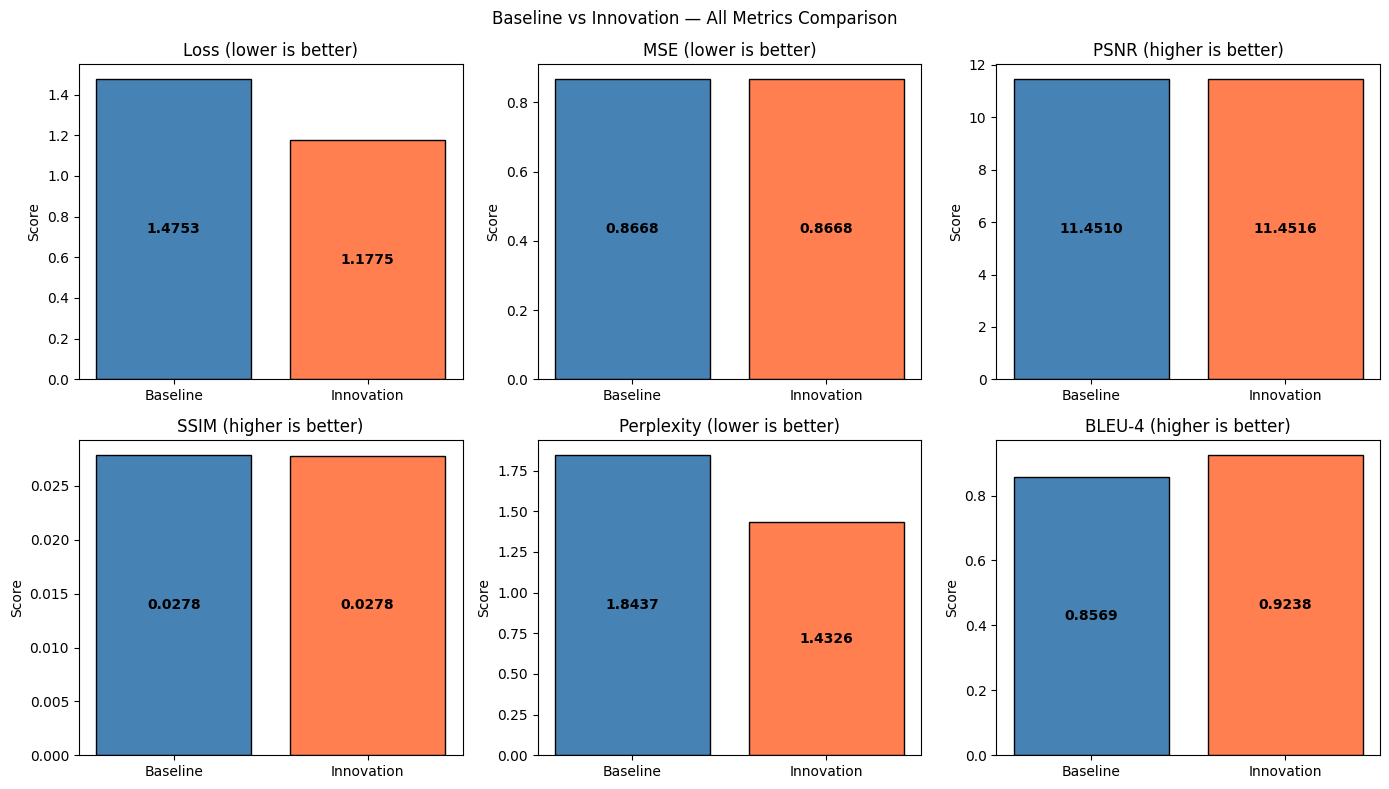

In [89]:
# Plotting all metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes      = axes.flatten()
metrics_plot = [
    ("Loss",       "loss",       "lower is better"),
    ("MSE",        "mse",        "lower is better"),
    ("PSNR",       "psnr",       "higher is better"),
    ("SSIM",       "ssim",       "higher is better"),
    ("Perplexity", "perplexity", "lower is better"),
    ("BLEU-4",     "bleu",       "higher is better"),
]
for ax, (name, key, note) in zip(axes, metrics_plot):
    values = [baseline_results[key], innovation_results[key]]
    bars   = ax.bar(["Baseline", "Innovation"], values,
                    color=["steelblue", "coral"], edgecolor="black")
    ax.set_title(f"{name} ({note})")
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f"{val:.4f}",
            ha="center", va="center",
            fontsize=10, fontweight="bold", color="black"
        )
plt.suptitle("Baseline vs Innovation — All Metrics Comparison")
plt.tight_layout()
plt.savefig("results/evaluation_all_metrics.png")
plt.show()

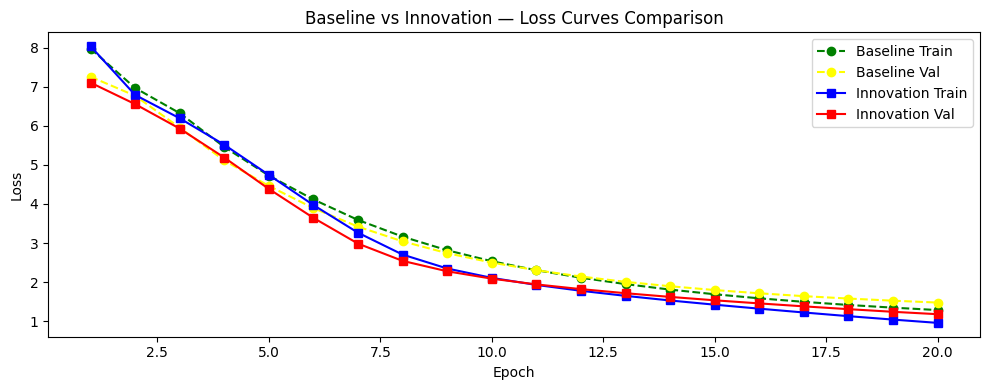

In [90]:
# Plotting baseline vs innovation loss curves together
plt.figure(figsize=(10, 4))
plt.plot(range(1, config["num_epochs"] + 1), train_losses,     label="Baseline Train",   linestyle="--", marker="o", color="green")
plt.plot(range(1, config["num_epochs"] + 1), val_losses,       label="Baseline Val",     linestyle="--", marker="o", color="yellow")
plt.plot(range(1, config["num_epochs"] + 1), inn_train_losses, label="Innovation Train", linestyle="-",  marker="s", color="blue")
plt.plot(range(1, config["num_epochs"] + 1), inn_val_losses,   label="Innovation Val",   linestyle="-",  marker="s", color="red")
plt.title("Baseline vs Innovation — Loss Curves Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("results/loss_curves_comparison.png")
plt.show()

In [91]:
# Saving results table to CSV for README
results_df = pd.DataFrame({
    "Metric":     ["Loss", "MSE", "PSNR", "SSIM", "Perplexity", "BLEU-4"],
    "Baseline":   [baseline_results[k]   for k in ["loss", "mse", "psnr", "ssim", "perplexity", "bleu"]],
    "Innovation": [innovation_results[k] for k in ["loss", "mse", "psnr", "ssim", "perplexity", "bleu"]],
})
results_df["Improvement"] = results_df.apply(
    lambda r: f"{((r['Baseline'] - r['Innovation']) / r['Baseline']) * 100:.1f}%"
    if r["Metric"] in ["Loss", "MSE", "Perplexity"]
    else f"{((r['Innovation'] - r['Baseline']) / r['Baseline']) * 100:.1f}%",
    axis=1
)
results_df.to_csv("results/evaluation_results.csv", index=False)
print(results_df.to_string(index=False))

    Metric  Baseline  Innovation Improvement
      Loss  1.475301    1.177475       20.2%
       MSE  0.866791    0.866791        0.0%
      PSNR 11.450962   11.451601        0.0%
      SSIM  0.027831    0.027800       -0.1%
Perplexity  1.843724    1.432550       22.3%
    BLEU-4  0.856946    0.923797        7.8%


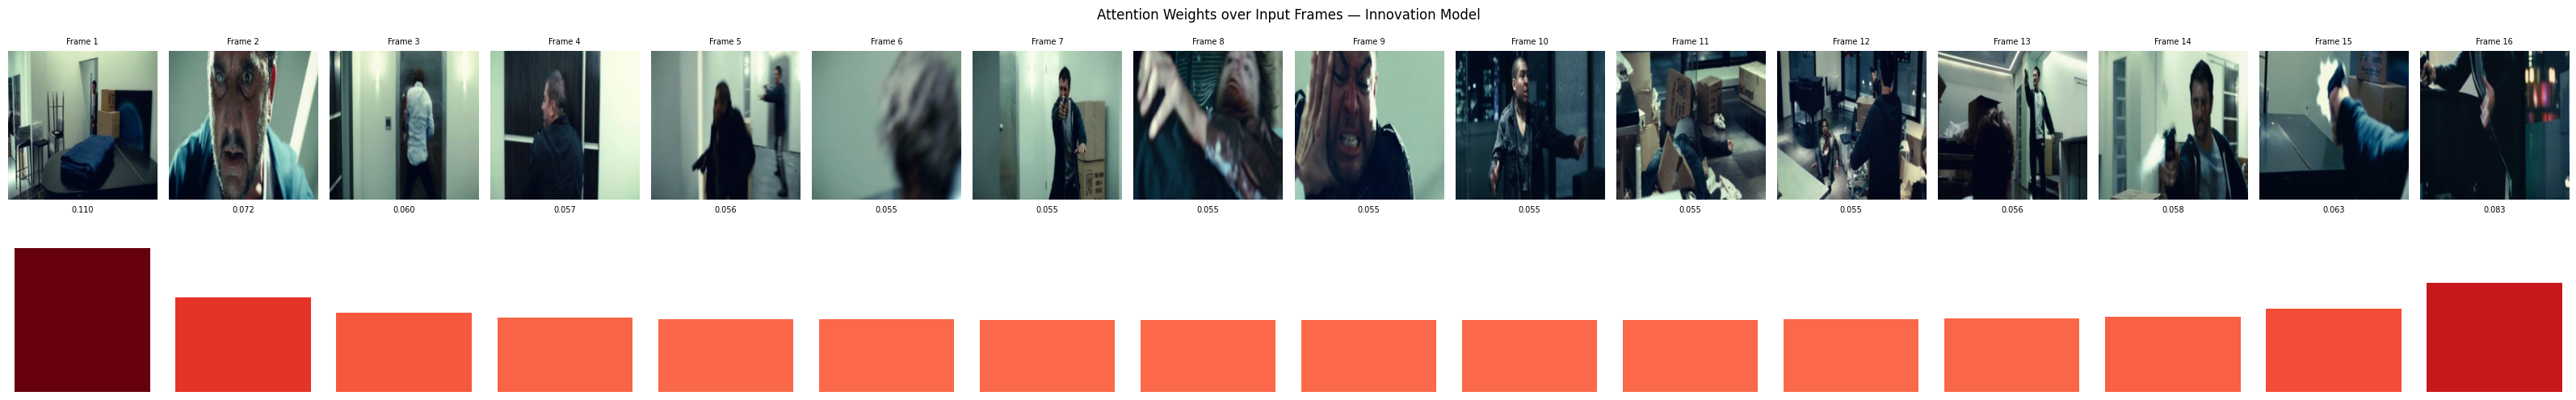

Attention weights: [0.10984804 0.07205109 0.06036983 0.05679199 0.05558945 0.05515866
 0.05499979 0.05494398 0.0549344  0.05495883 0.05503656 0.05524215
 0.05581326 0.05755102 0.06334054 0.08337046]
Most attended frame: 1 (weight: 0.1098)
Least attended frame: 9 (weight: 0.0549)


In [92]:
# Visualising attention weights across sequence frames
def visualize_attention(model, dataset, idx=0):
    model.eval()
    sample        = dataset[idx]
    input_images  = sample["input_images"].unsqueeze(0).to(device)
    text          = sample["text"].unsqueeze(0).to(device)
    with torch.no_grad():
        _, _, attn_weights = model(input_images, text, text)
    attn_weights = attn_weights.squeeze(0).cpu().numpy()
    K            = len(attn_weights)
    # Normalizing weights for color mapping
    norm_weights = (attn_weights - attn_weights.min()) / (attn_weights.max() - attn_weights.min() + 1e-8)
    colors       = plt.cm.RdYlGn(norm_weights)
    # Plotting frames with attention weights
    fig, axes = plt.subplots(2, K, figsize=(K * 2, 5))
    for i in range(K):
        # Plotting original frame
        img = sample["input_images"][i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Frame {i+1}", fontsize=7)
        axes[0, i].axis("off")
        # Plotting attention weight with gradient color
        axes[1, i].bar([0], [attn_weights[i]], color=colors[i])
        axes[1, i].set_ylim(0, attn_weights.max() * 1.2)
        axes[1, i].set_title(f"{attn_weights[i]:.3f}", fontsize=7)
        axes[1, i].axis("off")
    plt.suptitle("Attention Weights over Input Frames — Innovation Model\n(green=high attention, red=low attention)")
    plt.tight_layout()
    plt.savefig("results/explainability_attention_weights.png")
    plt.show()
    return attn_weights
attn = visualize_attention(innovation_model, train_ds, idx=0)
print(f"Attention weights: {attn}")
print(f"Most attended frame: {attn.argmax() + 1} (weight: {attn.max():.4f})")
print(f"Least attended frame: {attn.argmin() + 1} (weight: {attn.min():.4f})")

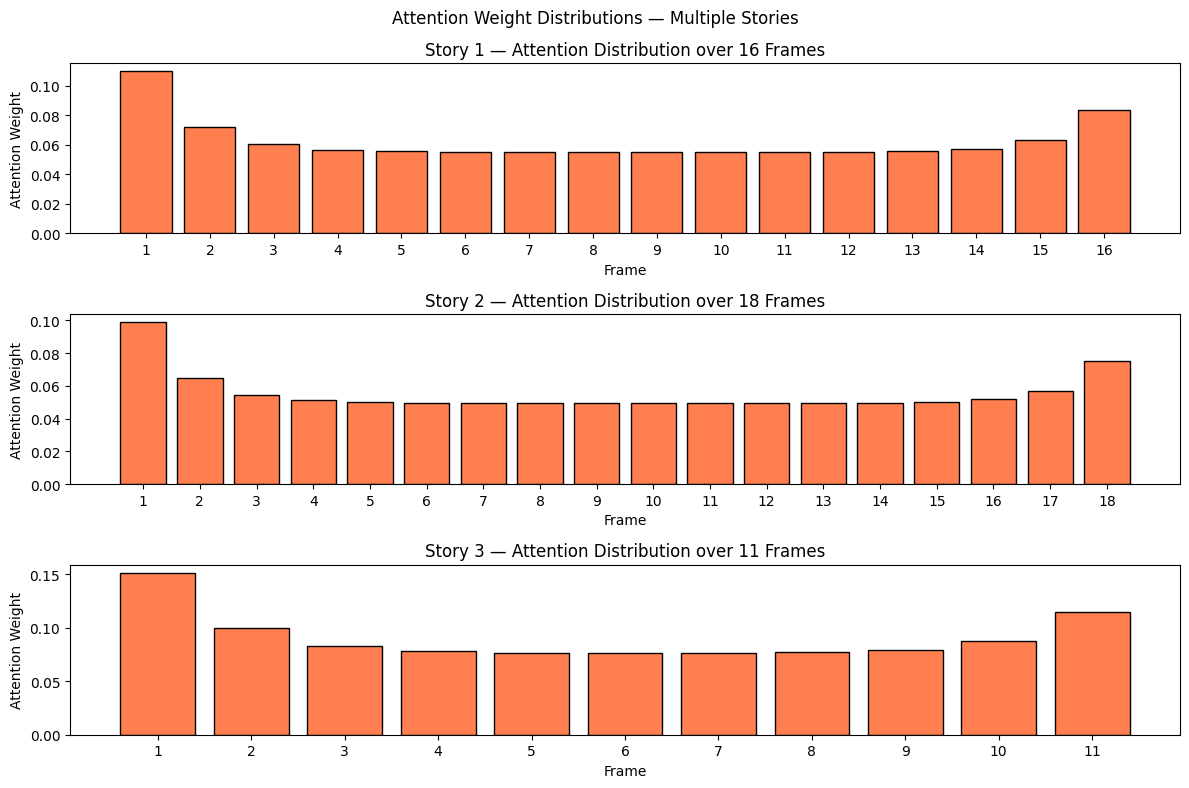

In [105]:
# Visualising attention patterns across multiple stories
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for row, idx in enumerate([0, 1, 2]):
    sample       = train_ds[idx]
    input_images = sample["input_images"].unsqueeze(0).to(device)
    text         = sample["text"].unsqueeze(0).to(device)
    with torch.no_grad():
        _, _, attn_weights = innovation_model(input_images, text, text)
    attn_weights = attn_weights.squeeze(0).cpu().numpy()
    K            = len(attn_weights)
    axes[row].bar(range(1, K + 1), attn_weights, color="coral", edgecolor="black")
    axes[row].set_title(f"Story {idx+1} — Attention Distribution over {K} Frames")
    axes[row].set_xlabel("Frame")
    axes[row].set_ylabel("Attention Weight")
    axes[row].set_xticks(range(1, K + 1))
plt.suptitle("Attention Weight Distributions — Multiple Stories")
plt.tight_layout()
plt.savefig("results/explainability_attention_distribution.png")
plt.show()

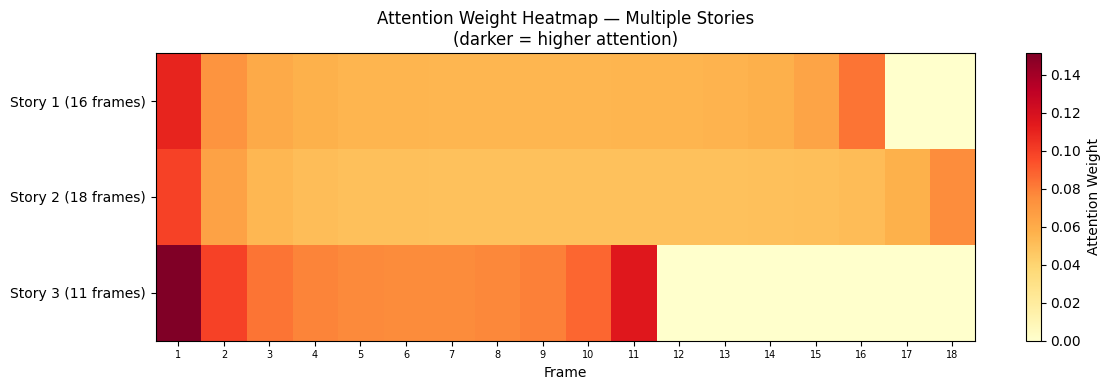

In [106]:
# Visualising attention patterns as heatmap across multiple stories
fig, ax = plt.subplots(figsize=(12, 4))
# Collecting attention weights for 3 stories
heatmap_data = []
story_labels = []
max_frames   = 0
for idx in [0, 1, 2]:
    sample       = train_ds[idx]
    input_images = sample["input_images"].unsqueeze(0).to(device)
    text         = sample["text"].unsqueeze(0).to(device)
    with torch.no_grad():
        _, _, attn_weights = innovation_model(input_images, text, text)
    attn_weights = attn_weights.squeeze(0).cpu().numpy()
    heatmap_data.append(attn_weights)
    story_labels.append(f"Story {idx+1} ({len(attn_weights)} frames)")
    max_frames = max(max_frames, len(attn_weights))
# Padding shorter stories with zeros for uniform grid
padded_data = np.zeros((3, max_frames))
for i, row in enumerate(heatmap_data):
    padded_data[i, :len(row)] = row
# Plotting heatmap
im = ax.imshow(padded_data, aspect="auto", cmap="YlOrRd", interpolation="nearest")
plt.colorbar(im, ax=ax, label="Attention Weight")
ax.set_yticks(range(3))
ax.set_yticklabels(story_labels)
ax.set_xlabel("Frame")
ax.set_xticks(range(max_frames))
ax.set_xticklabels([f"{i+1}" for i in range(max_frames)], fontsize=7)
ax.set_title("Attention Weight Heatmap — Multiple Stories\n(darker = higher attention)")
plt.tight_layout()
plt.savefig("results/explainability_attention_heatmap.png")
plt.show()

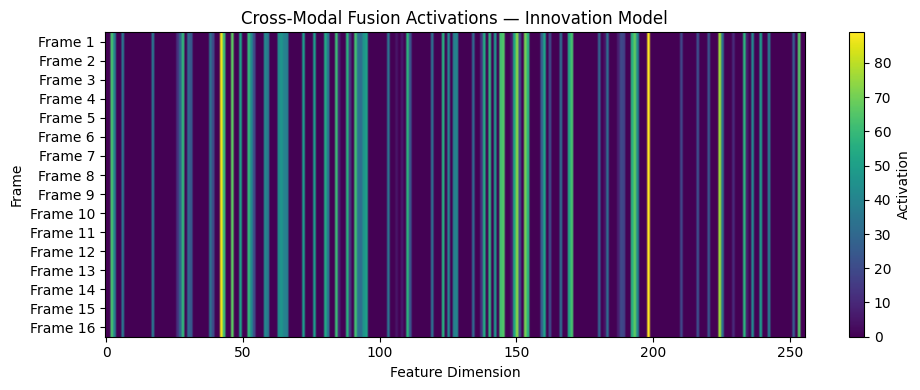

In [94]:
# Visualising cross-modal attention between visual and text features
def visualize_crossmodal_attention(model, dataset, idx=0):
    model.eval()
    sample        = dataset[idx]
    input_images  = sample["input_images"].unsqueeze(0).to(device)
    text          = sample["text"].unsqueeze(0).to(device)
    # Hooking into cross-modal fusion layer
    attention_maps = {}
    def hook_fn(module, input, output):
        attention_maps["fused"] = output.detach().cpu()
    hook = model.fusion.register_forward_hook(hook_fn)
    with torch.no_grad():
        visual_features = model.visual_encoder(input_images)
        text_features   = model.text_encoder(text)
        fused           = model.fusion(visual_features, text_features)
    hook.remove()
    fused_np = attention_maps["fused"].squeeze(0).numpy()
    K        = fused_np.shape[0]
    plt.figure(figsize=(10, 4))
    plt.imshow(fused_np, aspect="auto", cmap="viridis")
    plt.colorbar(label="Activation")
    plt.title("Cross-Modal Fusion Activations — Innovation Model")
    plt.xlabel("Feature Dimension")
    plt.ylabel("Frame")
    plt.yticks(range(K), [f"Frame {i+1}" for i in range(K)])
    plt.tight_layout()
    plt.savefig("results/explainability_crossmodal_fusion.png")
    plt.show()
visualize_crossmodal_attention(innovation_model, train_ds, idx=0)

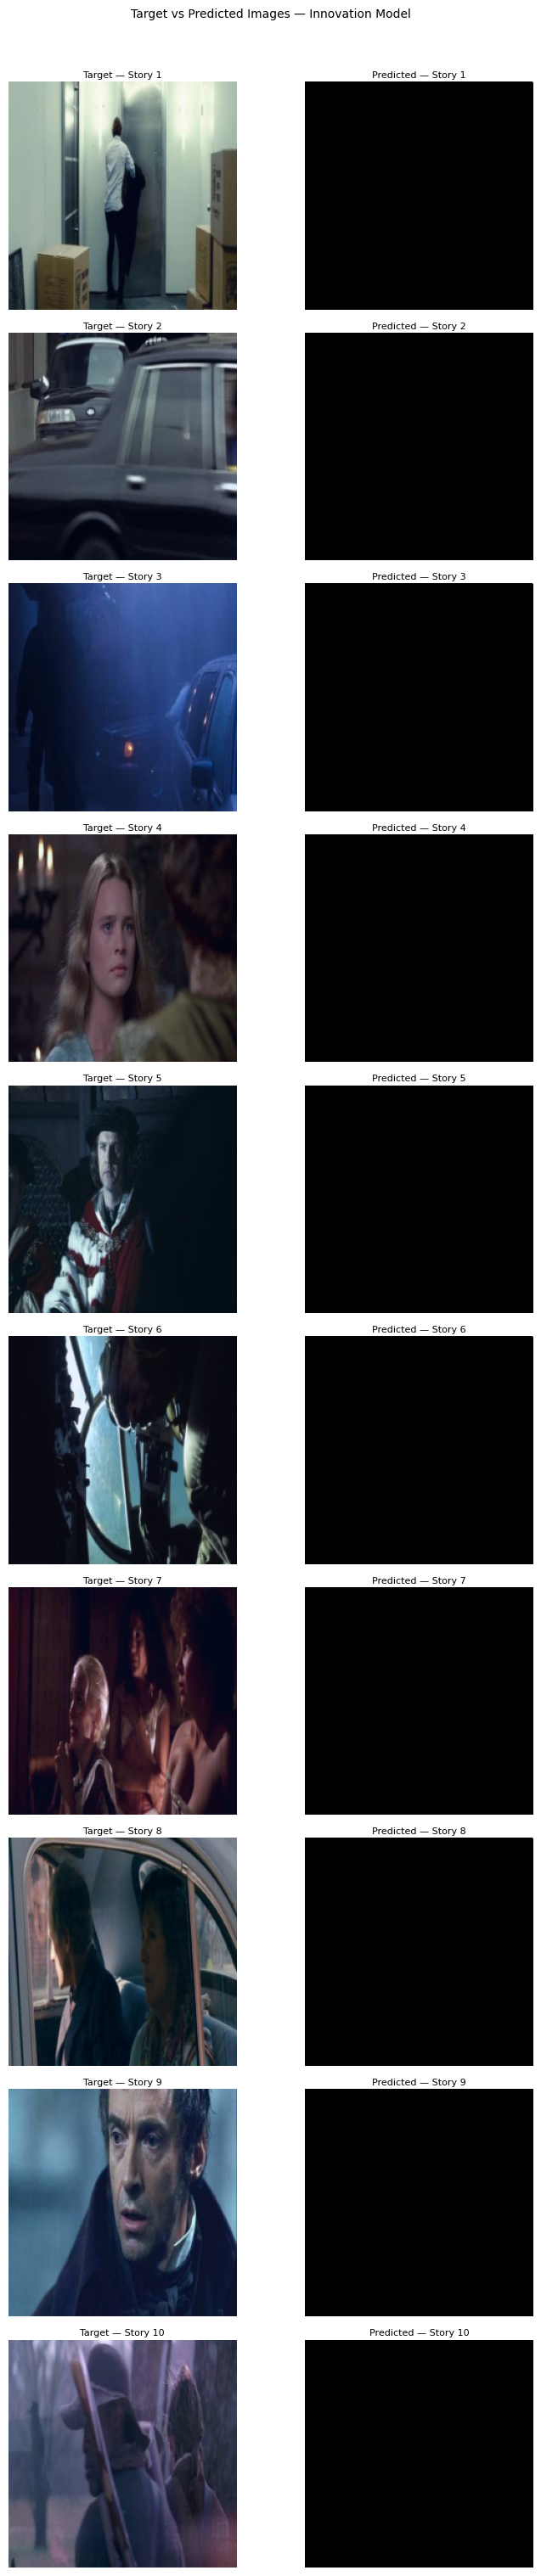

In [103]:
# Visualising predicted vs target images with 10 samples
def visualize_predictions(model, dataset, num_samples=10):
    model.eval()
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 3))
    for i in range(num_samples):
        sample        = dataset[i]
        input_images  = sample["input_images"].unsqueeze(0).to(device)
        text          = sample["text"].unsqueeze(0).to(device)
        with torch.no_grad():
            image_pred, _, _ = model(input_images, text, text)
        # Target image
        target_np = sample["target_image"].permute(1, 2, 0).numpy()
        target_np = (target_np - target_np.min()) / (target_np.max() - target_np.min() + 1e-8)
        # Predicted image
        pred_np = image_pred.squeeze(0).permute(1, 2, 0).cpu().numpy()
        pred_np = (pred_np - pred_np.min()) / (pred_np.max() - pred_np.min() + 1e-8)
        axes[i, 0].imshow(target_np)
        axes[i, 0].set_title(f"Target — Story {i+1}", fontsize=8, pad=3)
        axes[i, 0].axis("off")
        axes[i, 1].imshow(pred_np)
        axes[i, 1].set_title(f"Predicted — Story {i+1}", fontsize=8, pad=3)
        axes[i, 1].axis("off")
    plt.suptitle("Target vs Predicted Images — Innovation Model", fontsize=10, y=1.01)
    plt.tight_layout()
    plt.savefig("results/explainability_predictions.png", bbox_inches="tight")
    plt.show()
visualize_predictions(innovation_model, train_ds, num_samples=10)

In [107]:
import shutil
# Zipping and downloading results folder
shutil.make_archive("results", "zip", "results")
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>